In [1]:
import sys
sys.path.insert(1, '../../../Utils/')
from classes_unet import *
from sklearn.model_selection import KFold

number_of_the_seed = 2020

random.seed(number_of_the_seed)
set_seed(number_of_the_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

C:\Users\iisaragon\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\iisaragon\anaconda3\envs\torch\lib\site-packages\torch\nn\_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))


In [2]:
path=Path('../../../../Datasets/Processed/dataset/')
path_train=path/'train_def'
path_model=Path('../models/kfold_unet')

In [3]:
transforms=Compose([HorizontalFlip(p=0.5),Rotate(p=0.40,limit=10)],p=1)
transformPipeline=SegmentationAlbumentationsTransform(transforms)

In [4]:
img = PILImage.create(path_train/'Blast_PCRM_1201754 D5.BMP')
img = transform_image(img)

In [5]:
codes = np.array(['Background','ZP', 'TE', 'ICM'])

In [6]:
get_y_fn = lambda x: Path(str(x).replace("train_def","GT_Mask"))

In [7]:
bs = 2
callbacks = [EarlyStoppingCallback(patience=3),SaveModelCallback(fname='model'),ReduceLROnPlateau(patience=3)]
opt = ranger

In [8]:
def datablock(indx_valid):
    return DataBlock(blocks=(ImageBlock, MaskBlock(codes)),
              get_items=get_files,
              get_y=get_y_fn,
              splitter=IndexSplitter(indx_valid),
              item_tfms=[Resize((480,480)), TargetMaskConvertTransform(), transformPipeline],
              batch_tfms=Normalize.from_stats(*imagenet_stats))

In [9]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

## Entrenamiento

In [ ]:
k=1
for indx_train, indx_valid in kfold.split(get_files(path_train)):
    trainDB = datablock(indx_valid)
    trainDLS = trainDB.dataloaders(path_train,bs=bs)
    learn = unet_learner(trainDLS, resnet34, self_attention=True, act_cls=Mish, opt_func=opt,metrics=[DiceMulti()],cbs=callbacks)
    lr_steep=learn.lr_find()
    learn.fit_one_cycle(20,lr_steep)
    learn.fit_one_cycle(20,lr_steep)
    learn.unfreeze()
    lr_steep=learn.lr_find()
    learn.fit_one_cycle(5,lr_steep)
    #aux=learn.model
    #aux=aux.cpu()
    #img=img.cpu()
    #traced_cell=torch.jit.trace(aux, (img))
    #traced_cell.save(f"../../../../2_models/kfold_unet/{k}.pth")
    k+=1

## Testeo

In [4]:
import sys
sys.path.insert(1, '../Utils/')
from classes_unet import *
from metrics import *

In [5]:
path_test=path/'test_def'
files=[path_test/f for f in os.listdir(path_test)]
gtruth_zp=[get_mask(f,'ZP',path) for f in files]
gtruth_te=[get_mask(f,'TE',path) for f in files]
gtruth_icm=[get_mask(f,'ICM',path) for f in files]

In [15]:
ZP={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
TE={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
ICM={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
for k in range(1,11):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
    file=f"{k}.pth"
    model = torch.jit.load(path_model/file)
    model = model.cpu()
    preds=[prediccion(f,model) for f in files]
    preds_zp=[255*(p==75).astype('uint8') for p in preds]  
    preds_te=[255*(p==255).astype('uint8') for p in preds]
    preds_icm=[255*(p==150).astype('uint8') for p in preds]  
    metrics_zp=summary_metrics(gtruth_zp,preds_zp)
    for keys in ZP:
        ZP[keys].append(metrics_zp[keys])
    metrics_te=summary_metrics(gtruth_te,preds_te)
    for keys in TE:
        TE[keys].append(metrics_te[keys])
    metrics_icm=summary_metrics(gtruth_icm,preds_icm)
    for keys in ICM:
        ICM[keys].append(metrics_icm[keys])

In [26]:
def r(n):
    return(round(n,4))

In [27]:
for k in ZP:
    print(k + ': ' +str(r(np.mean(ZP[k]))),str(r(np.std(ZP[k]))))

accuracy: 0.9578 0.0023
precision: 0.9008 0.0118
recall: 0.772 0.0165
specificity: 0.9885 0.002
jaccard: 0.7213 0.0137
dice: 0.8257 0.0089


In [28]:
for k in TE:
    print(k + ': ' +str(r(np.mean(TE[k]))),str(r(np.std(TE[k]))))

accuracy: 0.9583 0.0029
precision: 0.8398 0.0221
recall: 0.7683 0.0203
specificity: 0.9819 0.0031
jaccard: 0.6683 0.0163
dice: 0.7927 0.0104


In [29]:
for k in ICM:
    print(k + ': ' +str(r(np.mean(ICM[k]))),str(r(np.std(ICM[k]))))

accuracy: 0.9746 0.003
precision: 0.8861 0.024
recall: 0.7501 0.0508
specificity: 0.9929 0.0024
jaccard: 0.6893 0.0381
dice: 0.7871 0.0309


In [18]:
for k in ZP:
    print(k + ': ' +str(ZP[k][0]))

accuracy: 0.961758311950877
precision: 0.9025688475818626
recall: 0.7948313921256919
specificity: 0.9891126109730578
jaccard: 0.7449340838251521
dice: 0.8402751312983735


In [23]:
for k in TE:
    print(k + ': ' +str(TE[k][0]))

accuracy: 0.9624469835114278
precision: 0.8601333013230801
recall: 0.7908218533622012
specificity: 0.9833802298722072
jaccard: 0.693884140174354
dice: 0.8081218525063342


In [24]:
for k in ICM:
    print(k + ': ' +str(ICM[k][0]))

accuracy: 0.9792594747208019
precision: 0.9082629267412339
recall: 0.81399785662643
specificity: 0.9920035907891092
jaccard: 0.742593162158957
dice: 0.8312785629712512


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
file=f"1.pth"
model = torch.jit.load(path_model/file)
model = model.cpu()
preds=[prediccion(f,model) for f in files]

In [7]:
img=cv2.imread(str(files[0]))

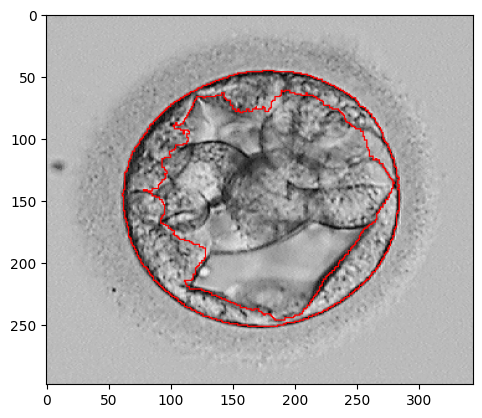

In [8]:
TE=255*(preds[0]==255).astype('uint8')
TE=cv2.dilate(TE, np.ones((3,3)))-TE
img[TE==255]=0
img[:,:,0][TE==255]=255

plt.imshow(img)

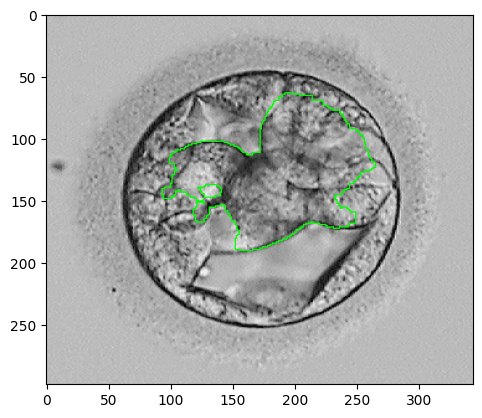

In [9]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

ICM=255*(preds[0]==150).astype('uint8')
ICM=cv2.erode(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))-ICM

img[ICM==255]=0
img[:,:,1][ICM==255]=255
plt.imshow(img)

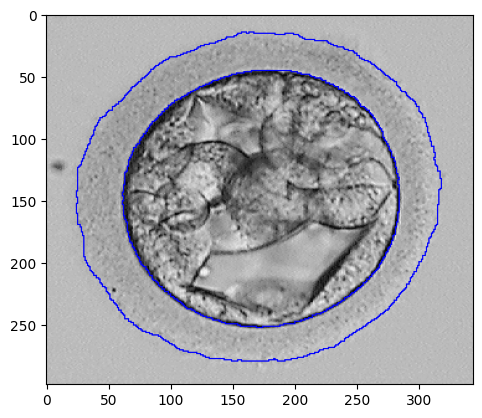

In [10]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

ZP=255*(preds[0]==75).astype('uint8')
ZP=cv2.erode(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))-ZP

img[ZP==255]=0
img[:,:,2][ZP==255]=255
plt.imshow(img)

In [20]:
files[0]

Path('../../../../Datasets/Processed/dataset/test_def/Blast_PCRM_d5.17.BMP')